In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

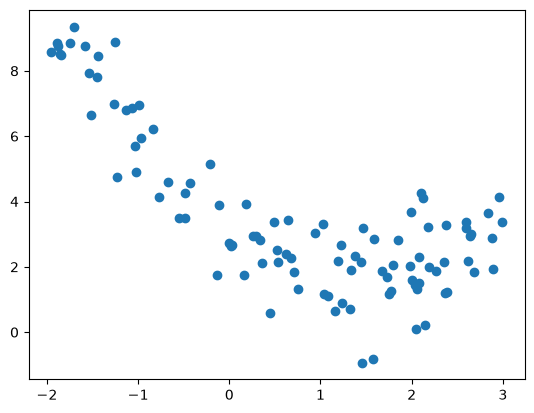

In [2]:
m = 100
x1 = 5*np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

c:\Users\nkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5722188945572769e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


<function matplotlib.pyplot.show(close=None, block=None)>

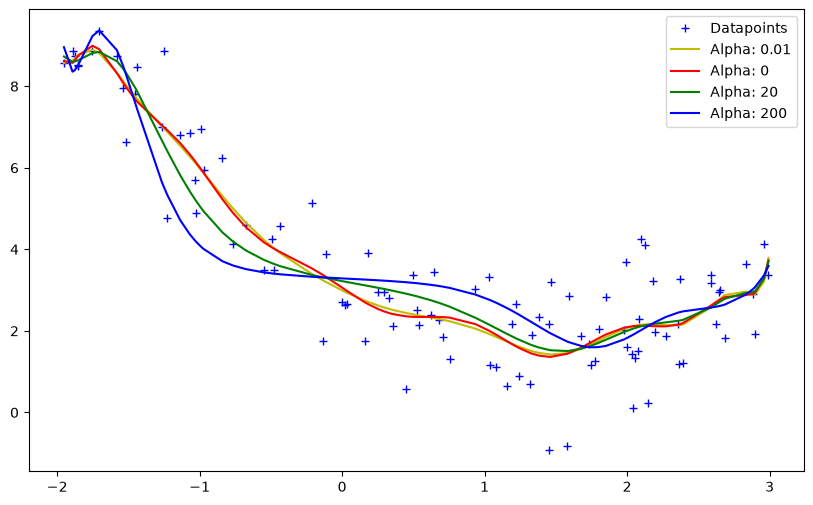

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)),
        ('ridge',Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0.01,0,20,200]
cs = ['y','r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Datapoints')

for alpha, c in zip(alphas,cs):
    preds = get_preds_ridge(x1,x2,alpha)

    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show